*   NAME: Sam George


# **Variational Autoencoder (VAE)**

**Part 1: Data Preparation and Exploration**

In [1]:
# Cell A: imports and data loaders
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Use transforms (optional normalization)
transform = transforms.Compose([
    transforms.ToTensor(),                   # values in [0,1]
    # transforms.Normalize((0.5,), (0.5,))  # optional if you change loss accordingly
])

# Datasets (will download into /content/data by default)
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Split validation from train
train_data, val_data = torch.utils.data.random_split(train_dataset, [50000, 10000])

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

def show_samples(dataset, n=8):
    images, _ = next(iter(DataLoader(dataset, batch_size=n)))
    grid = np.transpose(utils.make_grid(images, nrow=n).numpy(), (1,2,0))
    plt.figure(figsize=(10,2))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

# Quick preview (uncomment to display)
# show_samples(train_dataset)


ModuleNotFoundError: No module named 'torch'


* Loads MNIST dataset with images converted to tensors.
* Splits original training set into training (50K) and validation (10K).
* Creates DataLoaders for batching and efficient data loading during training/testing.
* `show_samples()` displays a few sample images in a grid using Matplotlib.
* `shuffle=True` in training improves learning; validation/testing kept consistent.
* `num_workers=2` allows faster data loading using parallel workers.



**Part 2: VAE Model Implementation**

In [ ]:
# VAE model (corrected __init__)
latent_dim = 20

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        log_var = self.fc_logvar(x)
        return mu, log_var

def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1)

    def forward(self, z):
        x = F.relu(self.fc(z))
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.deconv1(x))
        x = torch.sigmoid(self.deconv2(x))
        return x

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var


* **Encoder**

  * Uses two convolution layers to reduce image size and extract features
  * Flattens and outputs **mu** (mean) and **log_var** (log variance) for latent distribution

* **Reparameterization Trick**

  * Samples latent vector `z` using:
    `z = mu + std * random_noise`
  * Allows backpropagation through stochastic sampling

* **Decoder**

  * Maps latent vector back to image space
  * Uses a fully connected layer + transpose convolutions to reconstruct image
  * `sigmoid` ensures pixel values are between 0 and 1

* **VAE Model**

  * Combines encoder + decoder
  * Returns reconstructed image + latent parameters (`mu`, `log_var`) for loss calculation

**Part 3: Loss Function and Training**

In [ ]:
# training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# Loss: reconstruction (mean) + KL (mean)
def vae_loss(recon_x, x, mu, log_var):
    # if you normalized inputs with Normalize, adapt or use MSE
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')  # sum across batch
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # return per-batch sum; you can divide by batch size outside if needed
    return recon_loss + kl_loss

# Optionally: scheduler, checkpoint path
save_dir = "/content/drive/MyDrive/vae_mnist"  # change if Drive not mounted
os.makedirs(save_dir, exist_ok=True)


* **Device Selection**

  * Uses GPU (`cuda`) if available, otherwise CPU

* **Model & Optimizer**

  * Initializes VAE model
  * Uses Adam optimizer with learning rate **0.001**

* **VAE Loss Function**

  * **Reconstruction Loss:**
    Binary Cross Entropy — measures how well the output matches the input
  * **KL Divergence Loss:**
    Regularizes latent space to follow standard normal distribution
  * Total Loss = Reconstruction Loss + KL Loss

* **Saving Directory**

  * Creates folder to store model results/outputs in Google Drive


In [ ]:
# training loop
epochs = 10
best_val_loss = float('inf')

for epoch in range(epochs):
    vae.train()
    train_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = vae(data)
        loss = vae_loss(recon, data, mu, log_var)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader.dataset)

    # validation
    vae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in val_loader:
            data = data.to(device)
            recon, mu, log_var = vae(data)
            loss = vae_loss(recon, data, mu, log_var)
            val_loss += loss.item()
    val_loss /= len(val_loader.dataset)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.6f}  Val Loss: {val_loss:.6f}")

    # Save checkpoint
    ckpt_path = os.path.join(save_dir, f"vae_epoch{epoch+1}.pth")
    torch.save({'epoch': epoch+1, 'model_state': vae.state_dict(), 'optimizer_state': optimizer.state_dict()}, ckpt_path)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(vae.state_dict(), os.path.join(save_dir, "vae_best.pth"))



Epoch [1/10] Train Loss: 194.649606  Val Loss: 130.768735
Epoch [2/10] Train Loss: 119.856121  Val Loss: 114.871634
Epoch [3/10] Train Loss: 112.176575  Val Loss: 111.430421
Epoch [4/10] Train Loss: 109.324545  Val Loss: 108.947812
Epoch [5/10] Train Loss: 107.764081  Val Loss: 107.564967
Epoch [6/10] Train Loss: 106.621441  Val Loss: 106.877426
Epoch [7/10] Train Loss: 105.817106  Val Loss: 106.209625
Epoch [8/10] Train Loss: 105.157477  Val Loss: 105.732692
Epoch [9/10] Train Loss: 104.729579  Val Loss: 105.144602
Epoch [10/10] Train Loss: 104.253546  Val Loss: 104.911230


### **Training Loop**

* Runs for **10 epochs**

* **Training Phase**

  * Model set to `train()` mode
  * Forward pass → compute reconstruction + KL loss
  * Backprop + optimizer step to update weights
  * Tracks training loss

* **Validation Phase**

  * Model set to `eval()` mode (no gradient updates)
  * Loss computed on validation dataset
  * Tracks validation performance

* **Loss Averaging**

  * Loss divided by total number of samples for fair comparison

* **Checkpoint Saving**

  * Saves model and optimizer state after every epoch
  * Separately saves the **best model** (lowest validation loss)

* **Prints Loss Report**

  * Displays training and validation loss per epoch for monitoring learning


**Part 4: Generation and Latent Space Exploration**

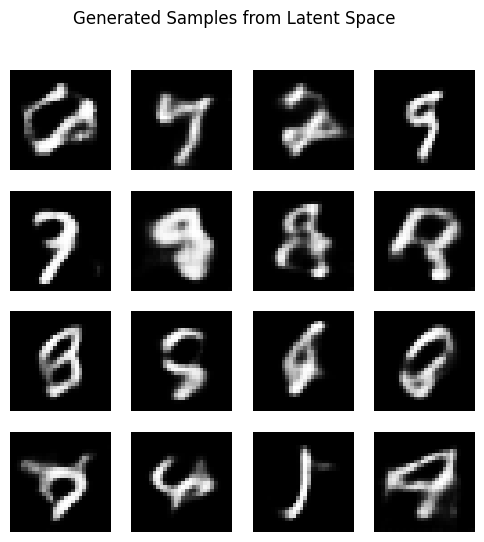

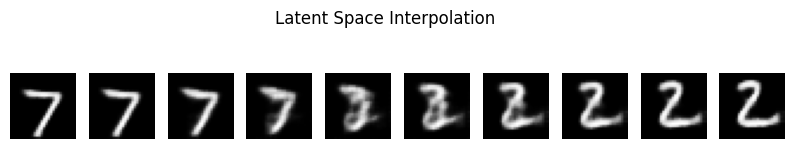

In [ ]:
# generate samples and interpolation
vae.eval()
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = vae.decoder(z).cpu()

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Samples from Latent Space')
plt.show()

# Latent interpolation between first two test images
def interpolate(a, b, steps=10):
    return torch.stack([a + (b - a) * t for t in torch.linspace(0, 1, steps)], dim=0)

with torch.no_grad():
    imgs, _ = next(iter(test_loader))
    x1, x2 = imgs[0].to(device), imgs[1].to(device)
    mu1, _ = vae.encoder(x1.unsqueeze(0))
    mu2, _ = vae.encoder(x2.unsqueeze(0))
    z_interp = interpolate(mu1, mu2, steps=10).squeeze(1)
    inter_images = vae.decoder(z_interp).cpu()

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(inter_images[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('Latent Space Interpolation')
plt.show()


### **Generated Samples from Latent Space**

* Model switched to `eval()` mode → no gradient updates
* Random noise `z` sampled from standard normal distribution
* Decoder converts `z` into new digit-like images
* Creates a **4×4 grid** showing 16 generated samples

### **Latent Space Interpolation**

* Picks two test images
* Encodes them into latent vectors (`mu1`, `mu2`)
* Linearly interpolates between the two latent points
* Decodes each intermediate point → smooth transformation between digits
* Visualizes transition in a **1×10 grid**